In [9]:
from aart_func import *
from params import * # The file params.py contains all the relevant parameters for the simulations
from paramsQU import*

#print black hole spin and inclination angle to check
print(f"BH spin: {spin_case}")
print(f"Observer's inclination: {i_case}")
print(f"r initial: {r_initial} M")
print(f"phi_initial: {phi_initial}")
print(f"(Br,Bth,Bphi)= ({Br},{Bth},{Bphi})")
print(f"sub_kep = {sub_kep}")
print(f"beta_r = {betar}")
print(f"beta_phi = {betaphi}")

BH spin: 0.94
Observer's inclination: 20
r initial: 11 M
phi_initial: 0
(Br,Bth,Bphi)= (0,1,0)
sub_kep = 1.0
beta_r = 0.9
beta_phi = 0.98


## INITIALIZATIONS

In [10]:
from matplotlib.collections import LineCollection

In [11]:
# Find limits for QU loop plots

def auto_limits(x1, y1, x2, y2, padding_factor=0.25, default_lim=(-0.2, 0.2)):
    """
    Automatically calculate xlim and ylim values for two sets of data with divergence handling.
    
    Parameters:
    x1 (array-like): x-coordinate data for first set
    y1 (array-like): y-coordinate data for first set
    x2 (array-like): x-coordinate data for second set
    y2 (array-like): y-coordinate data for second set
    padding_factor (float): percentage of range to add as padding (default: 0.25)
    default_lim (tuple): fallback limits when data is divergent (default: (-0.2, 0.2))
    
    Returns:
    tuple: (xlim, ylim) where each is a (min, max) tuple
    """
    # Convert to numpy arrays and take real parts
    x1 = np.asarray(x1).real
    y1 = np.asarray(y1).real
    x2 = np.asarray(x2).real
    y2 = np.asarray(y2).real
    
    def calculate_lim(data):
        # Handle empty data
        if len(data) == 0:
            return default_lim
        
        # Handle constant values
        if np.all(data == data[0]):
            center = data[0]
            return (center - 1, center + 1)  # Symmetric range around single value
        
        # Handle infinite or NaN values
        if not np.all(np.isfinite(data)):
            return default_lim
            
        # Calculate regular limits with padding
        data_min, data_max = np.nanmin(data), np.nanmax(data)
        data_range = data_max - data_min
        
        # Handle extremely large ranges (divergent cases)
        if data_range > 1e6:  # Adjust threshold as needed
            return default_lim
            
        padding = data_range * padding_factor
        return (data_min - padding, data_max + padding)
    
    # Combine x data from both sets for overall xlim
    xlim = calculate_lim(np.concatenate([x1, x2]))
    
    # Combine y data from both sets for overall ylim
    ylim = calculate_lim(np.concatenate([y1, y2]))
    
    return xlim, ylim


In [12]:
%time !python lensingbands.py


Thanks for using mAART
Copyright (C) 2026, P. Ruales, A. Cardenas-Avendano, D. Gates

Computing the lensing bands
Number of points in the n=0 grid  6760000
Number of points in the n=1 grid  676
Number of points in the n=2 grid  676
File  ./Results/LensingBands_a_0.940000_i_0.349066.h5  created.
CPU times: user 25.4 ms, sys: 29.5 ms, total: 55 ms
Wall time: 11.7 s


In [13]:
%time !python raytracing.py


Thanks for using mAART
Copyright (C) 2026, P. Ruales, A. Cardenas-Avendano, D. Gates

Ray-tracing
Reading file:  ./Results/LensingBands_a_0.940000_i_0.349066.h5
Analytical ray-tracing of the n=0 band points
Analytical ray-tracing of the n=1 band points
Analytical ray-tracing of the n=2 band points
File  ./Results/Rays_a_0.940000_i_0.349066.h5  created.

A total of 6761352 photons were ray-traced
CPU times: user 58.3 ms, sys: 37.7 ms, total: 96.1 ms
Wall time: 18.8 s


In [14]:
%time !python3 runQU.py


Thanks for using mAART
Copyright (C) 2026, P. Ruales, A. Cardenas-Avendano, D. Gates

File  ./QU_data/QUdata_i20_s0.94_B(0,1,0)_subkep_1.0_betar_0.9_betaphi_0.98_rinit_11_phiinit_0_gfactor_2.h5  created.
CPU times: user 21.7 ms, sys: 15.5 ms, total: 37.2 ms
Wall time: 5.2 s


## INSPIRALING HOTSPOTS

## QU Loops

In [15]:

QUdata=f"QU_data/QUdata_i{i_case}_s{spin_case}_B({Br},{Bth},{Bphi})_subkep_{sub_kep}_betar_{betar}_betaphi_{betaphi}_rinit_{r_initial}_phiinit_{phi_initial}_gfactor_{gfactor}.h5"
print("Reading file: ",QUdata)

h5f = h5py.File(QUdata,'r')

t_traj = h5f['t_traj'][:]
r_traj = h5f['r_traj'][:]
phi_traj = h5f['phi_traj'][:]
Q = h5f['Q'][:]
U = h5f['U'][:]
t_ray = h5f['t_ray'][:]

h5f.close()

Reading file:  QU_data/QUdata_i20_s0.94_B(0,1,0)_subkep_1.0_betar_0.9_betaphi_0.98_rinit_11_phiinit_0_gfactor_2.h5


Text(0.5, 1.0, 'B=(0,1,0)   a=0.94   $θ_i =$20$^{\\circ}$')

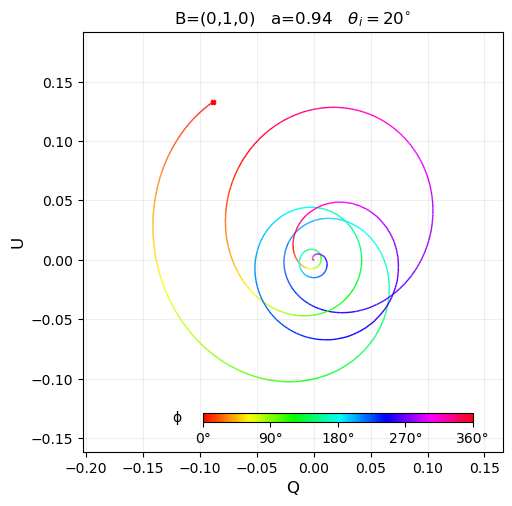

In [16]:
# Example QU loop ( r > ISCO )

fig, ax = plt.subplots(figsize=[6,6])
plt.subplots_adjust(left=0.15, right=0.85, top=0.85, bottom=0.15)

# Load phi values
phi_norm = (phi_traj) % (2 * np.pi)

# Plotting code adapted for the subplot
phi_subset_degrees = np.degrees(phi_norm)
xlim, ylim = auto_limits(Q, U, Q, U)

# Create segments for LineCollection
points = np.array([Q, U]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Create a continuous colormap
cmap = plt.get_cmap('hsv')

# Create a LineCollection object
lc = LineCollection(segments, cmap=cmap, linewidth=1)
lc.set_array(phi_subset_degrees)  # Set colors based on phi values
line = ax.add_collection(lc)

x0, y0 = Q[0], U[0]
ax.scatter(x0, y0, s=10, marker="X", color="r", zorder=4)

# Add colorbar inset inside the plot
# Values are in figure fraction coordinates: [left, bottom, width, height]
cbar_ax = fig.add_axes([0.35, 0.2, 0.45, 0.015])  # [x, y, width, height]
cbar = plt.colorbar(lc, cax=cbar_ax, orientation="horizontal")
cbar_ax.text(-0.08, 0.5, "ϕ", transform=cbar_ax.transAxes, ha='right', va='center', fontsize=10)
#cbar.set_label("ϕ")
cbar.set_ticks(np.arange(0, 361, 90))
cbar.set_ticklabels([f"{t}°" for t in np.arange(0, 361, 90)])

# Plot configuration
#ax.plot(0, 0, "xk",zorder=1)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel("Q", fontsize=12)
ax.set_ylabel("U", fontsize=12)
ax.grid(alpha=0.2)
ax.legend(loc='upper right', bbox_to_anchor=(1, 1),frameon=False, fontsize=10)
ax.set_title(f"B=({Br},{Bth},{Bphi})   a={spin_case}   " + r"$θ_i =$" + f"{i_case}" + r"$^{\circ}$")

## Q vs t
## U vs t

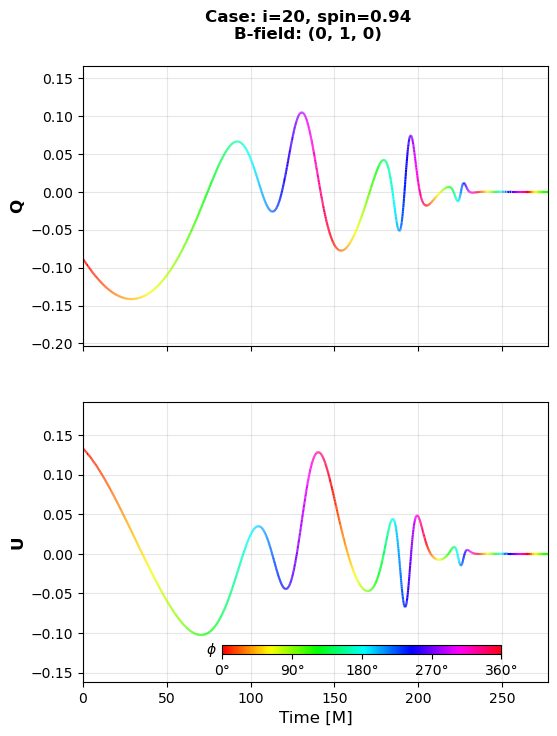

In [17]:
# Setup the figure (2 rows for Q and U)
fig, (ax_q, ax_u) = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

# Calculate Y limits using your existing function
xlim_Q, ylim_U = auto_limits(Q, U, Q, U)

# --- PLOTTING ---
plot_configs = [
    (ax_q, Q, xlim_Q, "Q"),
    (ax_u, U, ylim_U, "U")
]

phi_norm = (phi_traj) % (2 * np.pi)
phi_subset_degrees = np.degrees(phi_norm)

delta_t = t_ray[0] - t_ray
t_shifted = t_traj + delta_t

last_lc = None

for ax, data_y, y_limit, ylabel in plot_configs:
    # Create the color-coded line
    points = np.array([t_shifted, data_y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap='hsv', linewidth=1.5)
    lc.set_array(phi_subset_degrees)
    ax.add_collection(lc)
    last_lc = lc 
    
    # Set limits and styling
    ax.set_xlim(0, t_shifted[-1])
    ax.set_ylim(y_limit)
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)

# --- FINISHING TOUCHES ---
ax_q.legend(loc='upper right', frameon=False, fontsize=10)
ax_u.set_xlabel("Time [M]", fontsize=12)

# Add the colorbar to the U plot as an inset
cbar_ax = ax_u.inset_axes([0.3, 0.1, 0.6, 0.03]) 
cbar = fig.colorbar(last_lc, cax=cbar_ax, orientation="horizontal")
cbar_ax.text(-0.02, 0.5, r"$\phi$", transform=cbar_ax.transAxes, ha='right', va='center', fontsize=10, fontweight='bold')
cbar.set_ticks(np.arange(0, 361, 90))
cbar.set_ticklabels([f"{t}°" for t in np.arange(0, 361, 90)], fontsize=10)

plt.suptitle(f"Case: i={i_case}, spin={spin_case}\nB-field: ({Br}, {Bth}, {Bphi})", fontsize=12, fontweight='bold', y=0.95)
plt.show()